<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-001.png" class="img-responsive"/>
</div>

device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


train subset size: 1024


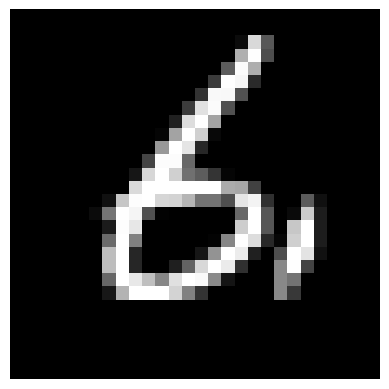

tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], device='cuda:0')


In [ ]:
# @title Load Dataset and Pick Example Image

import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -----------------------------
# 1) Data (RANDOM subset)
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# ----- KEY PART: RANDOM SUBSET -----
N_TRAIN = 1024  # size of subset

# make it reproducible for teaching (change/remove seed if you want new samples)
random.seed(42)

all_indices = list(range(len(train_full)))
random.shuffle(all_indices)
subset_indices = all_indices[:N_TRAIN]

train_ds = Subset(train_full, subset_indices)

# -----------------------------------

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

example_img = train_ds[0][0].to(device)
example_expected = torch.nn.functional.one_hot(torch.tensor(train_ds[0][1]), num_classes=10).float().unsqueeze(0).to(device)

print("train subset size:", len(train_ds))

plt.figure()
plt.imshow(example_img.cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

print(example_expected)

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-001.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-003.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-004.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-005.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-006.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-007.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-008.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-009.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-010.png" class="img-responsive"/>
</div>

In [ ]:
W = (0.01 * torch.randn(784, 10, device=device)).requires_grad_(True)
b = torch.zeros(10, device=device, requires_grad=True)

def forward(x_batch):
    x_flat = x_batch.view(x_batch.size(0), -1)
    return x_flat @ W + b

In [ ]:
# @title Evaluate on Test Set

@torch.no_grad()
def evaluate(loader):
    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = forward(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        seen += x.size(0)
    return total_loss / seen, correct / seen

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture08/slide-011.png" class="img-responsive"/>
</div>

In [ ]:
lr = 0.01
epochs = 25

train_losses, train_accs = [], []
test_losses, test_accs = [], []

print(f"[epoch 0]")
example_prediction_probs = torch.nn.functional.softmax(forward(example_img), dim=1).tolist()[0]
print(f'\tPrediction for sample image:', [f'{x:.4f}' for x in example_prediction_probs])
print(f'\tExpected for sample image:  ', [f'{x:.4f}' for x in example_expected[0].tolist()])
example_loss = F.cross_entropy(forward(example_img), example_expected).tolist()
print(f'\tLoss for sample image:', round(example_loss, 4))

for epoch in range(1, epochs + 1):
    total_loss, correct, seen = 0.0, 0, 0


    x_train, y_train = next(iter(train_loader))
    x_train = x_train.to(device)
    y_train = y_train.to(device)

    logits = forward(x_train)
    loss = F.cross_entropy(logits, y_train)
    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad
        W.grad.zero_()
        b.grad.zero_()

    preds = logits.argmax(dim=1)
    acc = (preds == y_train).float().mean().item()


    train_losses.append(loss.item())
    te_loss, te_acc = evaluate(test_loader)
    test_losses.append(te_loss);  test_accs.append(te_acc)

    print(f"[epoch {epoch:02d}] loss={te_loss:.4f} acc={te_acc*100:.2f}%")
    example_prediction_probs = torch.nn.functional.softmax(forward(example_img), dim=1).tolist()[0]
    print(f'\tPrediction for sample image:', [f'{x:.4f}' for x in example_prediction_probs])
    print(f'\tExpected for sample image:  ', [f'{x:.4f}' for x in example_expected[0].tolist()])
    example_loss = F.cross_entropy(forward(example_img), example_expected).tolist()
    print(f'\tLoss for sample image:', round(example_loss, 4))

[epoch 0]
	Prediction for sample image: ['0.0897', '0.0569', '0.1038', '0.0886', '0.0496', '0.0904', '0.2679', '0.0529', '0.0766', '0.1236']
	Expected for sample image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	Loss for sample image: 1.317
[epoch 01] loss=1.4772 acc=67.53%
	Prediction for sample image: ['0.1001', '0.0504', '0.0982', '0.0764', '0.0420', '0.1159', '0.2366', '0.0487', '0.0665', '0.1651']
	Expected for sample image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	Loss for sample image: 1.4414
[epoch 02] loss=1.4294 acc=69.33%
	Prediction for sample image: ['0.0988', '0.0485', '0.0836', '0.0765', '0.0383', '0.1140', '0.2905', '0.0423', '0.0692', '0.1383']
	Expected for sample image:   ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000']
	Loss for sample image: 1.2362
[epoch 03] loss=1.3868 acc=71.10%
	Predictio